# Task 1: Exploratory Data Analysis (EDA)

## Objective
Develop a thorough understanding of the financial news dataset through exploratory analysis. This involves descriptive statistics, text analysis, and time-series analysis.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Download stopwords if not already present
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Amor\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## 1. Load Data

In [9]:
data_path = "../data/raw/raw_analyst_ratings.csv"

if os.path.exists(data_path):
    # Note: Loading only a subset if the file is too large for memory, 
    # but for full analysis we'll use the whole thing.
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print("Error: Dataset not found at specified path.")

Dataset loaded successfully with 1407328 rows and 6 columns.


## 2. Preliminary Data Inspection

In [10]:
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


## 3. Descriptive Statistics

### Headline Length Distribution

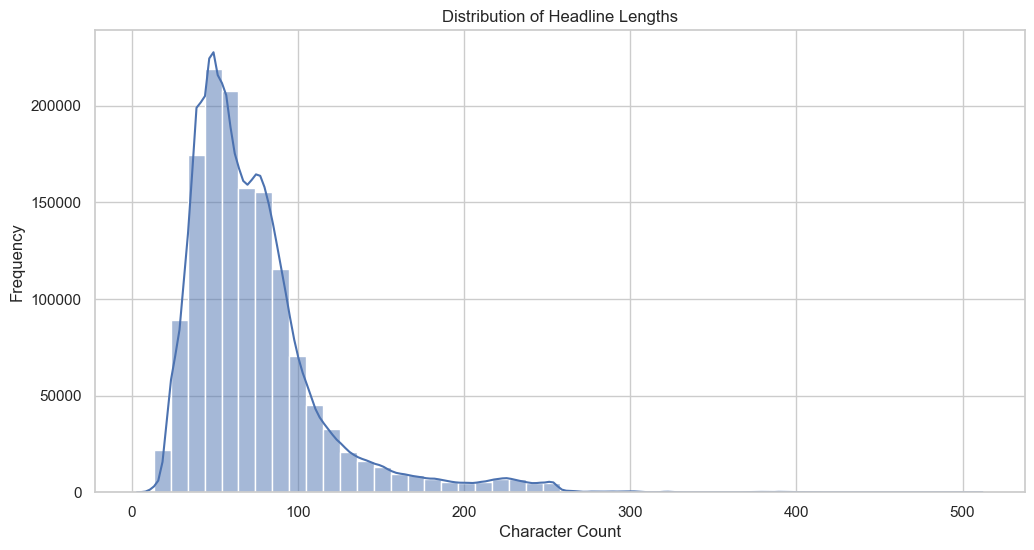

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


In [12]:
df['headline_len'] = df['headline'].apply(len)
sns.histplot(df['headline_len'], bins=50, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

print(df['headline_len'].describe())

### Articles per Publisher

C:\Users\Amor\AppData\Local\Temp\ipykernel_24900\3062282983.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')


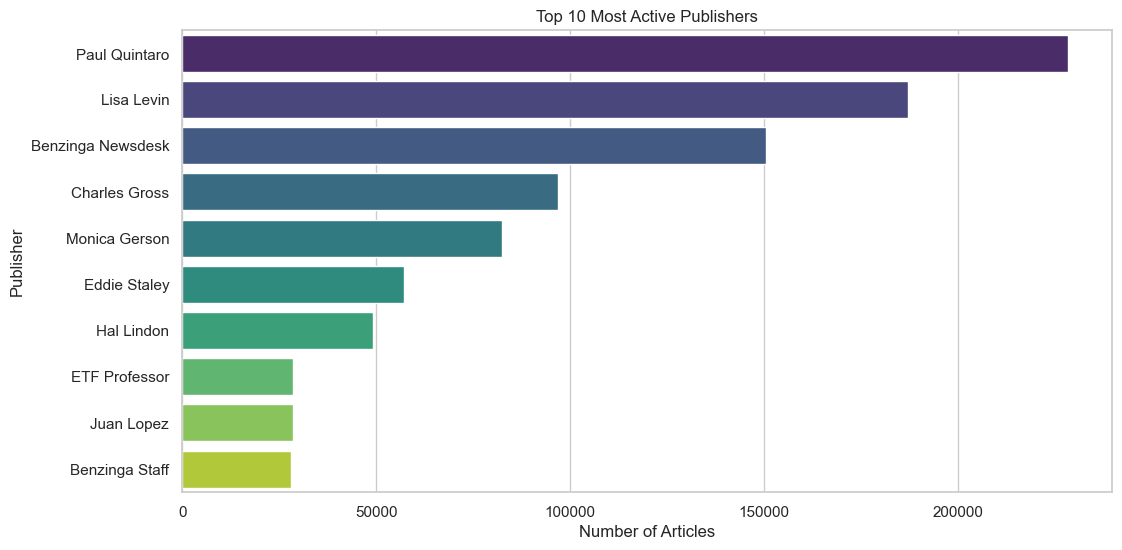

In [13]:
publisher_counts = df['publisher'].value_counts()
top_publishers = publisher_counts.head(10)

sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='viridis')
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.show()

## 4. Time Series Analysis of News Volume

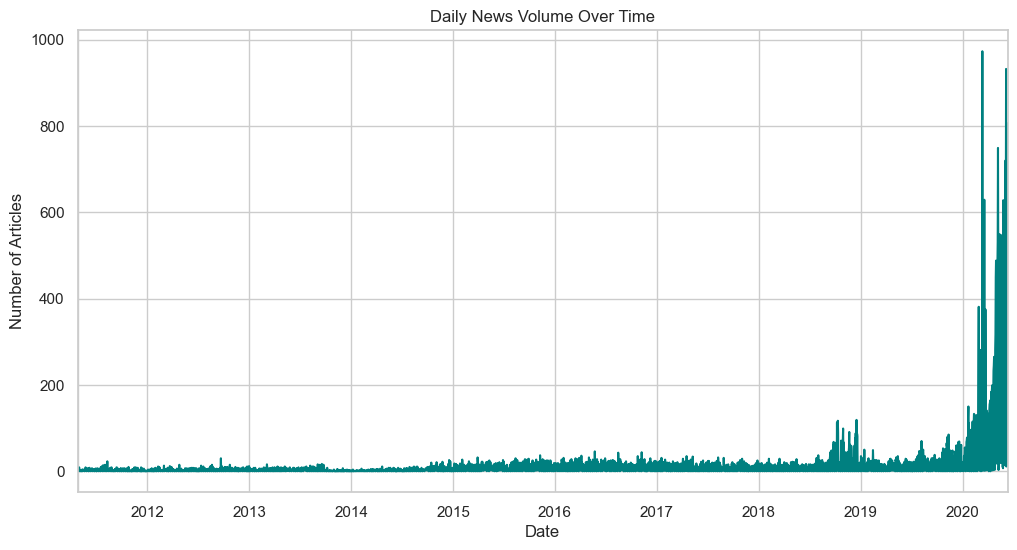

In [14]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check for null dates and drop if necessary for time analysis
df_time = df.dropna(subset=['date'])

# Plot resampled by day
df_time.set_index('date').resample('D').size().plot(color='teal')
plt.title('Daily News Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.show()

C:\Users\Amor\AppData\Local\Temp\ipykernel_24900\694095783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df_time, palette='magma')


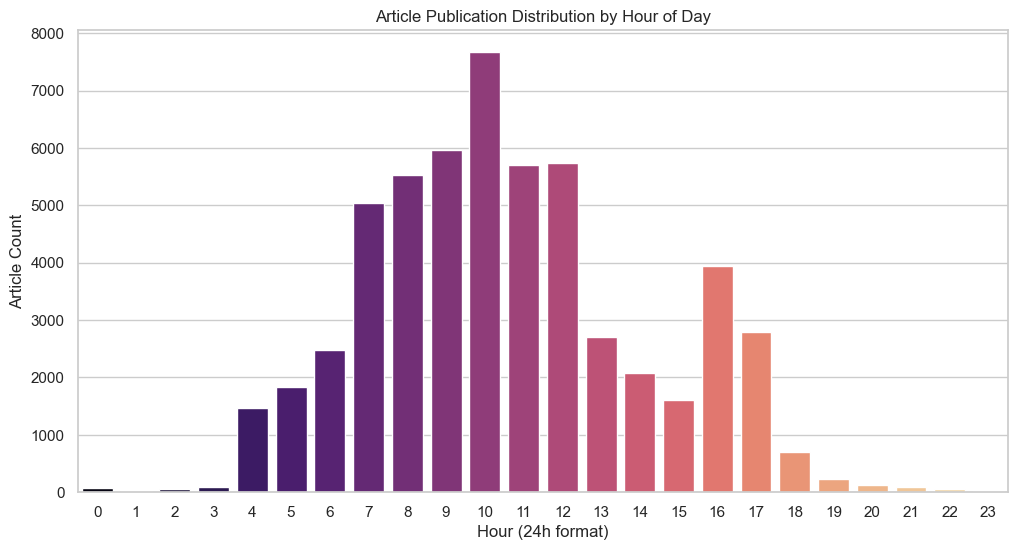

In [15]:
# Analyze publishing times (Hour of the day)
df_time['hour'] = df_time['date'].dt.hour
sns.countplot(x='hour', data=df_time, palette='magma')
plt.title('Article Publication Distribution by Hour of Day')
plt.xlabel('Hour (24h format)')
plt.ylabel('Article Count')
plt.show()

## 5. Text Analysis: Topic & Keyword Extraction

C:\Users\Amor\AppData\Local\Temp\ipykernel_24900\80642829.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=df_words, palette='Blues_r')


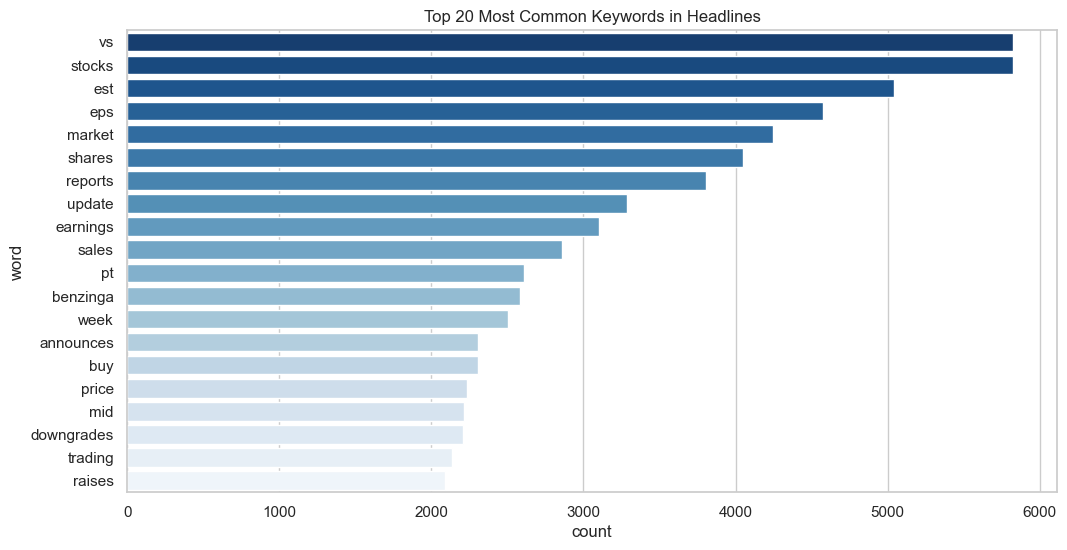

In [16]:
def get_top_n_words(corpus, n=None, n_gram_range=(1,1)):
    """
    List the top n words/phrases in a vocabulary according to occurrence in a text corpus.
    """
    vec = CountVectorizer(stop_words='english', ngram_range=n_gram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Sample headlines for faster processing if dataset is huge
sample_headlines = df['headline'].dropna().sample(min(50000, len(df)))

# Get top Unigrams (Single words)
common_words = get_top_n_words(sample_headlines, 20)
df_words = pd.DataFrame(common_words, columns=['word', 'count'])

sns.barplot(x='count', y='word', data=df_words, palette='Blues_r')
plt.title('Top 20 Most Common Keywords in Headlines')
plt.show()

C:\Users\Amor\AppData\Local\Temp\ipykernel_24900\3691490986.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='phrase', data=df_bigrams, palette='Reds_r')


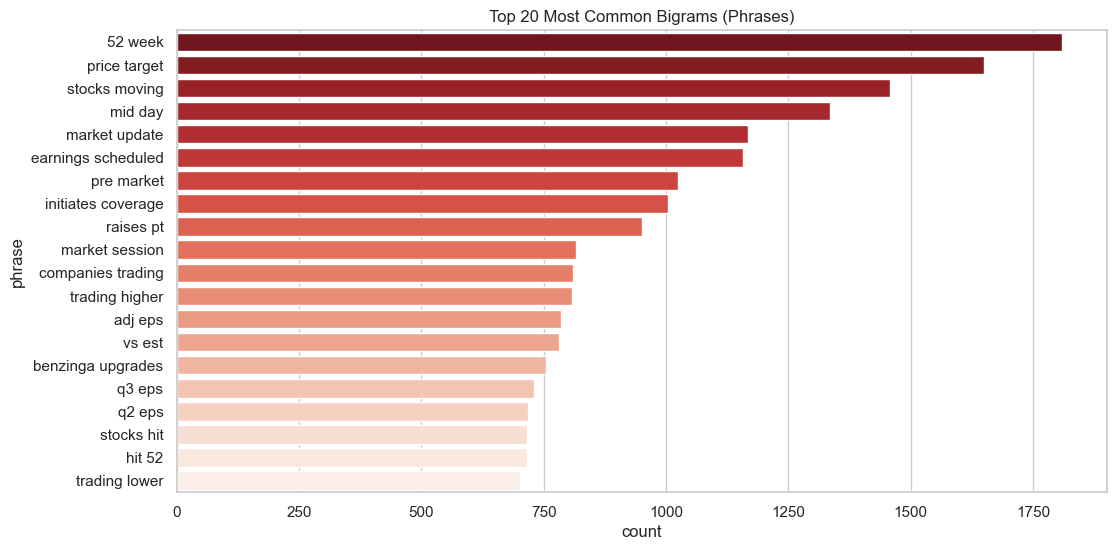

In [17]:
# Get top Bigrams (Two-word phrases like "FDA approval", "Price target")
common_bigrams = get_top_n_words(sample_headlines, 20, n_gram_range=(2,2))
df_bigrams = pd.DataFrame(common_bigrams, columns=['phrase', 'count'])

sns.barplot(x='count', y='phrase', data=df_bigrams, palette='Reds_r')
plt.title('Top 20 Most Common Bigrams (Phrases)')
plt.show()

## 6. Summary of Findings
1. **Headline Length:** Insights about character count distribution.
2. **Publishers:** Identification of top contributors.
3. **Time Trends:** Spikes in publication volume and daily publication patterns.
4. **Topics:** Recurring themes identified through keyword and phrase analysis.